Problem 1: Decision Trees

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss

In [42]:
# import fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets 
  
# metadata 
#print(spambase.metadata) 
  
# variable information 
#print(spambase.variables) 


1. Use an existing package to train a decision tree on the SPAMBASE training data, without pruning. Use the information gain splitting criteria. Compute the training and the testing error, accuracy, F1 score, and AUC and report these metrics. Write down some observations about the training and testing metrics.

In [54]:
# split data into training and test sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# train decision tree with information gain splitting criteria
tree_info_gain = tree.DecisionTreeClassifier(criterion='entropy')
tree_info_gain.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [56]:
# outputs:
rows = []

for train_or_test, x, y_true in [("Train", X_train, y_train),
                                  ("Test",  X_test,  y_test)]:
    
    y_pred = tree_info_gain.predict(x)

    rows.append({
        "Train or Test": train_or_test,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Error": log_loss(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_pred)
    })


pd.DataFrame(rows).set_index("Train or Test")

,Accuracy,Error,F1,AUC
Train or Test,,,,
Train,0.999457,0.019589,0.999297,0.999297
Test,0.932682,2.426391,0.919897,0.930045


observations about training and testing metrics:

2. Change the splitting criteria to use the Gini index. and report the same metrics. Compare them to the information gain metrics.

In [77]:
tree_gini = tree.DecisionTreeClassifier(criterion='gini')
tree_gini.fit(X_train, y_train)

DecisionTreeClassifier()

In [78]:
# outputs:
rows = []

for train_or_test, x, y_true in [("Train", X_train, y_train),
                                  ("Test",  X_test,  y_test)]:
    
    y_pred = tree_gini.predict(x)

    rows.append({
        "Train or Test": train_or_test,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Error": log_loss(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_pred)
    })


pd.DataFrame(rows).set_index("Train or Test")

,Accuracy,Error,F1,AUC
Train or Test,,,,
Train,0.999457,0.019589,0.999297,0.999297
Test,0.916395,3.013422,0.899083,0.911495


Compare results to information gain metrics

3. Implement a pruning criteria that sets an upper bound on the maximum depth of the tree. Generate a graph that plots the training and
testing error as a function of the tree depth on the SPAMBASE data. Please explain your observations. What is the optimal depth of the
tree that you would recommend based on this analysis?

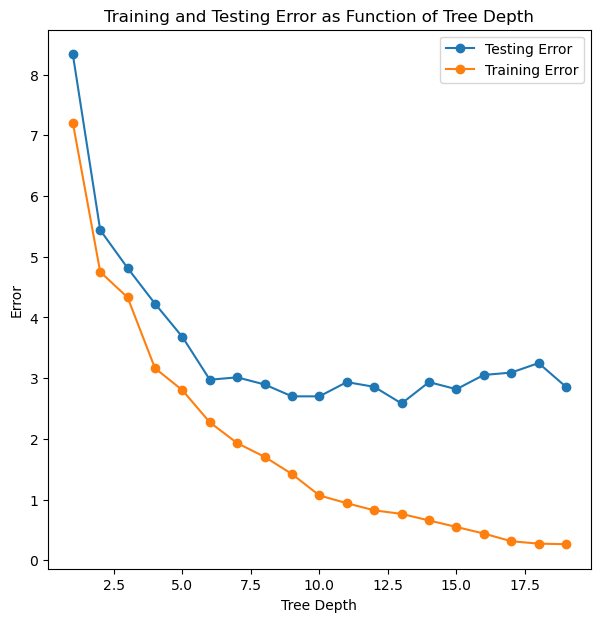

In [76]:
training_errors = []
testing_errors = []

max_depths = range(1, 20)

for depth in max_depths:
    dt = tree.DecisionTreeClassifier(max_depth=depth)
    dt.fit(X_train, y_train)

    y_pred_test = dt.predict(X_test)
    y_pred_train = dt.predict(X_train)

    testing_errors.append(log_loss(y_test, y_pred_test))
    training_errors.append(log_loss(y_train, y_pred_train))

plt.figure(figsize=(7,7))
plt.plot(max_depths, testing_errors, label='Testing Error',  marker='o')
plt.plot(max_depths, training_errors, label='Training Error',  marker='o')
plt.xlabel('Tree Depth')
plt.ylabel('Error')
plt.title('Training and Testing Error as Function of Tree Depth')
plt.legend()
plt.show()

The optimal depth of a tree I would reccommend based on this graph would be higher and closer to 20. Based on the graph, as the depth of the tree increases, the error decreases so a higher tree depth would be reccommended.